### **SUPERSTORE DATA ANALYTICS PROJECT**



**2.1. Import required libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns

**2.2. Load superstore data to pandas dataframe**

In [2]:
file_path = r"C:\Users\emman\OneDrive\Desktop\hero\project\1.Completed\Superstore_Data_Analytics_Project\3.Cleaned_Superstore_Dataset.csv"
df = pd.read_csv(file_path)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Day,Month_Year,Profit_Margin,Ship Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2.0,0.00,41.9136,2016,11,8,2016-11,0.1600,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3.0,0.00,219.5820,2016,11,8,2016-11,0.3000,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2.0,0.00,6.8714,2016,6,12,2016-06,0.4700,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5.0,0.45,-383.0310,2015,10,11,2015-10,-0.4000,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2.0,0.20,2.5164,2015,10,11,2015-10,0.1125,7


#### **3. Exploratory Data Analysis (EDA):**



**3.1. Basic Statistics**

In [3]:
basic_stat = df[['Sales', 'Profit', 'Profit_Margin']].describe().round(2)
print(basic_stat)

          Sales   Profit  Profit_Margin
count   9986.00  9986.00        9986.00
mean     229.78    28.61           0.12
std      623.37   234.32           0.47
min        0.44 -6599.98          -2.75
25%       17.25     1.73           0.08
50%       54.38     8.64           0.27
75%      209.88    29.35           0.36
max    22638.48  8399.98           0.50


**3.2. Group Analysis**

1. What category generates the highest revenue?

In [4]:
# 1. Sales by Category
sales_by_category = df.groupby('Category')['Sales'].sum().round(2).sort_values(ascending=False).reset_index()
print(sales_by_category)

          Category      Sales
0       Technology  835714.14
1        Furniture  741288.85
2  Office Supplies  717626.14


2. What region generates the highest profit?

In [5]:
# 2. Profit by Region
profit_by_region = df.groupby('Region')['Profit'].sum().round(2).sort_values(ascending=False).reset_index()
print(profit_by_region)

    Region     Profit
0     West  108406.14
1     East   91201.78
2    South   46423.33
3  Central   39706.36


3. What time period shows peak sales?

In [6]:
# 3. Monthly Trend of Sales
month_name = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_trends = df.groupby('Month')['Sales'].sum().round(2).reset_index()
monthly_trends['Month'] = month_name

print(monthly_trends)

        Month      Sales
0     January   94924.84
1    February   59751.25
2       March  204822.77
3       April  137130.40
4         May  155028.81
5        June  152718.68
6        July  147125.52
7      August  159044.06
8   September  307613.11
9     October  200322.98
10   November  351372.31
11   December  324774.39


4. Top 5 most profitable products per category

In [7]:
# Sum of Profit by Category and Product Name
product_profit = df.groupby(['Category', 'Product Name'])['Profit'].sum().reset_index()

# Top 5 Most profitable products per category
top_profitable = product_profit.sort_values(['Category', 'Profit'], ascending=[True, False]).groupby('Category').head(5).round()
display(top_profitable)

,Category,Product Name,Profit
218,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",1927.0
169,Furniture,Global Deluxe High-Back Manager's Chair,1559.0
231,Furniture,Hon Pagoda Stacking Chairs,1541.0
210,Furniture,Hon 4070 Series Pagoda Armless Upholstered Sta...,1389.0
306,Furniture,Office Star - Professional Matrix Back Chair w...,1306.0
764,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0
878,Office Supplies,Ibico EPK-21 Electric Binding System,3345.0
857,Office Supplies,Honeywell Enviracaire Portable HEPA Air Cleane...,3247.0
763,Office Supplies,Fellowes PB300 Plastic Comb Binding Machine,2518.0
880,Office Supplies,Ibico Ibimaster 300 Manual Binding System,2318.0


5. The 5 most loss-making products per category

In [8]:
# Loss making products per category
top_loss = product_profit.sort_values(['Category', 'Profit'], ascending=[True, True]).groupby('Category').head(5).round()
display(top_loss)

,Category,Product Name,Profit
63,Furniture,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.0
42,Furniture,Bush Advantage Collection Racetrack Conference...,-1934.0
21,Furniture,Balt Solid Wood Round Tables,-1201.0
37,Furniture,BoxOffice By Design Rectangular and Half-Moon ...,-1148.0
312,Furniture,"Riverside Furniture Oval Coffee Table, Oval En...",-1147.0
788,Office Supplies,GBC DocuBind P400 Electric Binding System,-1878.0
920,Office Supplies,Martin Yale Chadless Opener Electric Letter Op...,-1299.0
387,Office Supplies,3.6 Cubic Foot Counter Height Office Refrigerator,-872.0
1172,Office Supplies,Tennsco Single-Tier Lockers,-826.0
1072,Office Supplies,"SAFCO Commercial Wire Shelving, Black",-635.0


#### **4. Data Visualizations:**

**Question 1: Which product categories generate the most revenue, and how much does each contribute to total sales?**

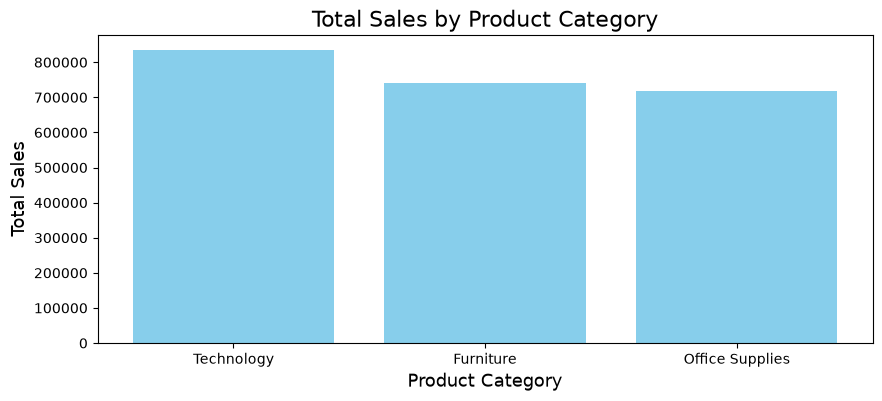

In [9]:
# Plot 1: Bar chart -> Sales by Product Category
fig, axes = plt.subplots(figsize=(10, 4))

if 'Category' in df.columns:
    axes.bar(sales_by_category['Category'], sales_by_category['Sales'], color='skyblue')
    axes.set_title('Total Sales by Product Category', fontsize=16)
    axes.set_xlabel('Product Category', fontsize=13)
    axes.set_ylabel('Total Sales', fontsize=13)

    plt.show()

**Key Insight:** Technology generates the highest revenue, totaling **&#36;835,714.14**. Furniture follows with **&#36;741,288.85**, and Office Supplies rounds out the categories with **&#36;$717,626.14**.



**Question 2: How does sales performance change across the year, and which months drive the strongest revenue**

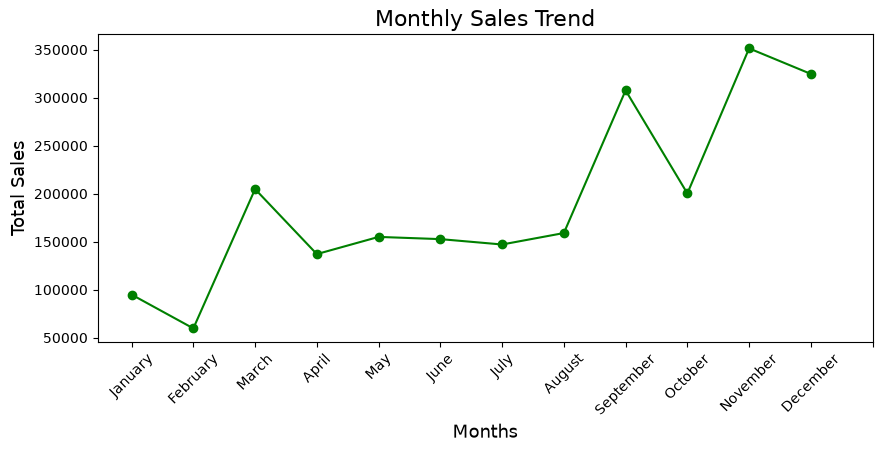

In [10]:
# Plot 2: Line chart -> Trend over time (Monthly Sales)
fig, axes = plt.subplots(figsize=(10, 4))

if 'Month' in df.columns:
    axes.plot(monthly_trends['Month'], monthly_trends['Sales'], marker='o', linestyle='-', color='green')
    axes.set_title('Monthly Sales Trend', fontsize=16)
    axes.set_xlabel('Months', fontsize=13)
    axes.set_ylabel('Total Sales', fontsize=13)
    axes.set_xticks(range(0, 13))
    axes.tick_params(axis='x', rotation=45)

**Key Insight:** The late fall and holiday shopping season is the undeniable peak performance period. November is the highest-grossing month at **&#36;351,372.31**, followed closely by December (**&#36;324,774.39**) and September (**&#36;307,613.11**).

In [11]:

monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index().sort_values('Month_Year')
fig_line = px.line(monthly_sales, x='Month_Year', y='Sales', title="Sales Trend Over Time", markers=True)
fig_line.update_layout(xaxis_title="Month-Year", yaxis_title="Total Sales ($)")

**Question 3: Which geographic regions contribute the most to total sales and profit, and how is revenue distributed across regions?**

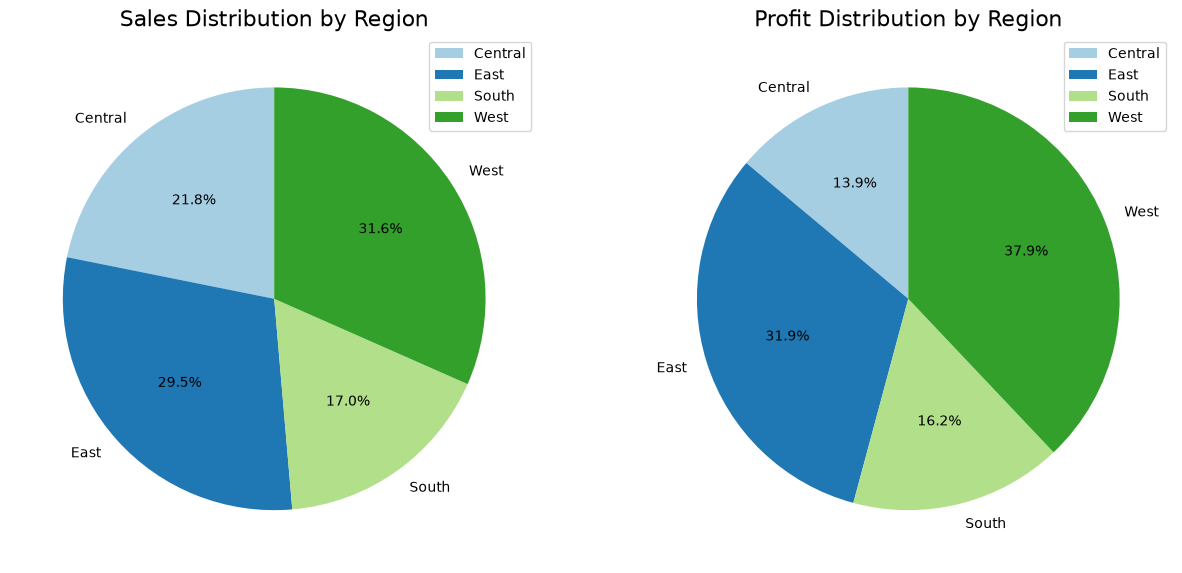

In [12]:
# Plot 3: Pie chart -> Distribution (Sales by Region), ~sales by customer segment
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

if 'Region' in df.columns:
    sales_by_region = df.groupby('Region')['Sales'].sum()
    axes[0].pie(sales_by_region, labels=sales_by_region.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    axes[0].set_title('Sales Distribution by Region', fontsize=16)
    axes[0].legend()

    profit_by_region = df.groupby('Region')['Profit'].sum()
    axes[1].pie(profit_by_region, labels=sales_by_region.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    axes[1].set_title('Profit Distribution by Region', fontsize=16)
    axes[1].legend()

plt.show()

**Key Insights:** The West region performs best overall. It leads in both total sales (**&#36;725,368.28**) and total profit (**&#36;108,406.14**). The East region is the runner-up, generating **&#36;91,201.78** in profit.

**3.3.4: How much variability and outlier risk exists within each category's order values?**

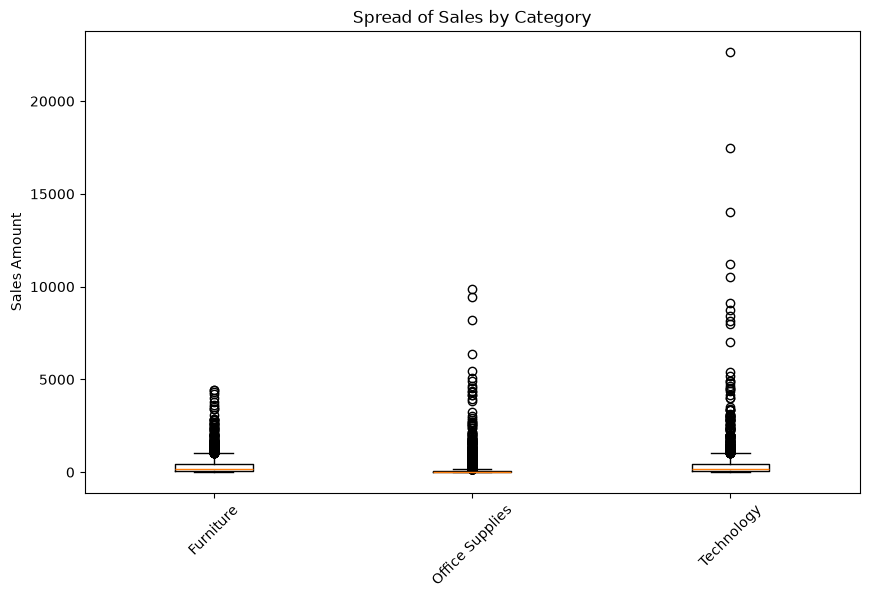

In [13]:
# Plot 4: Box plot -> Spread of values (Sales split by Category)
fig, axes = plt.subplots(figsize=(10, 6))

if 'Category' in df.columns:
    categories = df['Category'].dropna().unique()
    # Create a list of arrays (one for each category's sales)
    sales_data = [df[df['Category'] == cat]['Sales'].dropna() for cat in categories]

    axes.boxplot(sales_data, tick_labels=categories)
    axes.set_title('Spread of Sales by Category')
    axes.set_ylabel('Sales Amount')
    axes.tick_params(axis='x', rotation=45)

**Key Insights:** There are extreme outliers in both revenue and profit. While the average order value is only **&#36;229.78**, the maximum single order reached a massive **&#36;22,638.48**.
Furthermore, there are significant anomalies in profitability;
the largest single loss on an order was **-&#36;6,599.98** (a Cubify CubeX 3D Printer), showing that deep discounts or high costs occasionally severely damage margins

**Question 5: Is there a relationship between the discount rate applied and the resulting profit?**

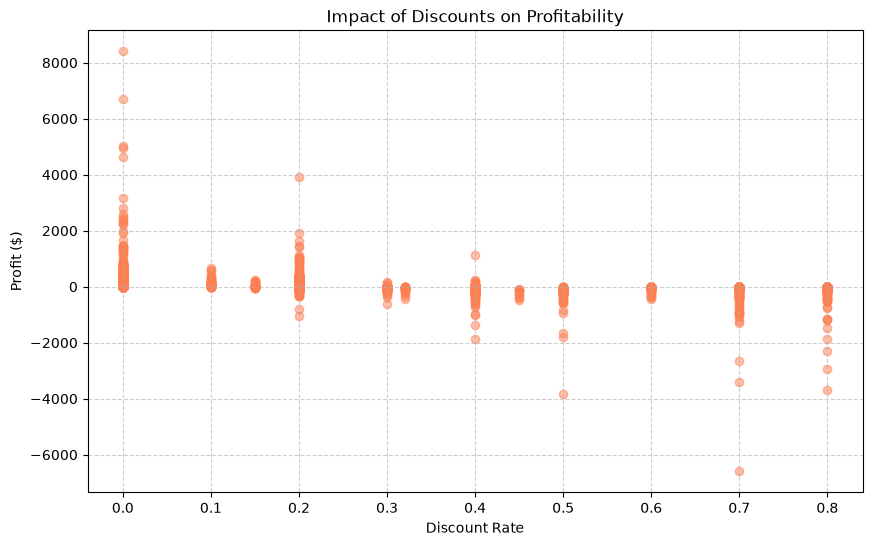

In [14]:
import seaborn as sns

# Plot 5: Scatter Plot showing the relationaship between Discount and Profit
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5, color='coral')
plt.title('Impact of Discounts on Profitability')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.grid(True, linestyle='--', alpha=0.6)

**Key Insight:** Impact of Discounts on Profitability:
This chart clearly illustrates the danger of over-discounting.
As the discount rate increases along the x-axis, the profit plunges significantly below zero, confirming that heavy discounts are the primary driver of major financial losses on individual transactions.

**Question 6: Which specific sub-categories are the biggest profit drivers versus the biggest loss-makers?**

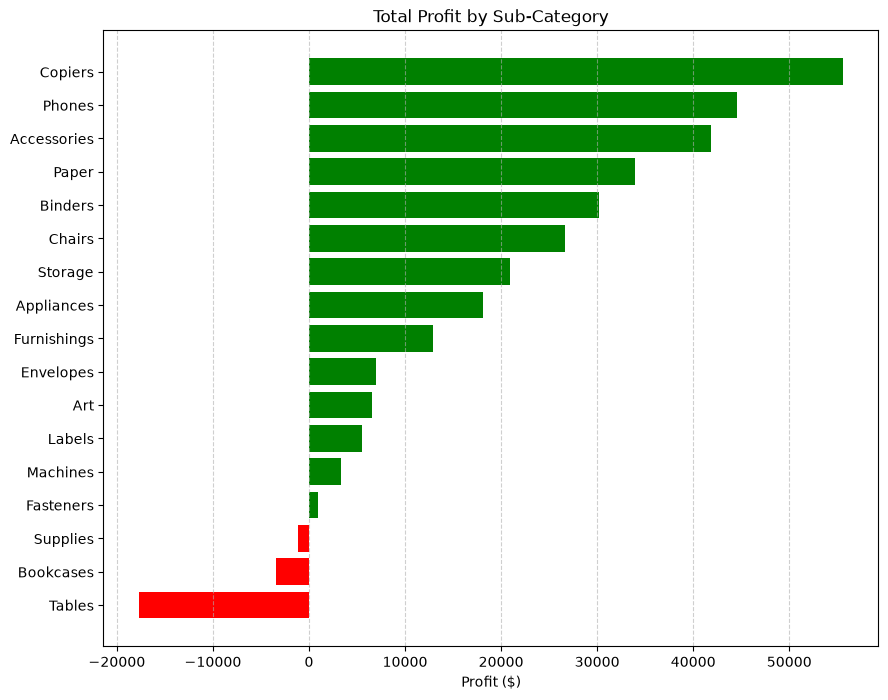

In [15]:
# Plot 6: Horizontal Bar Chart - Total Profit by Product Sub-Category
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in subcat_profit]
plt.figure(figsize=(10, 8))
plt.barh(subcat_profit.index, subcat_profit.values, color=colors)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.grid(axis='x', linestyle='--', alpha=0.6)

**Key Insight:** Total Profit by Sub-Category;
Breaking down the high-level categories reveals hidden issues.
While Furniture as a whole might seem fine, this chart highlights that "Tables" and "Bookcases" are consistently losing money for the business (shown in red). Conversely, "Copiers" and "Phones" are massive profit drivers.

**Question 7: How does the customer segment mix vary by region, and which regions rely most heavily on a particular segment?**

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Central'),
  Text(1, 0, 'East'),
  Text(2, 0, 'South'),
  Text(3, 0, 'West')])

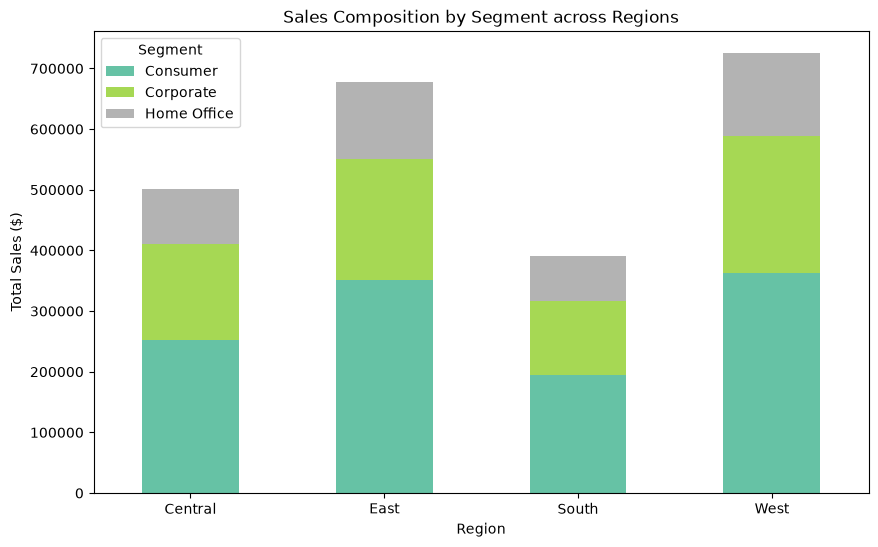

In [16]:
# Plot 7: Stacked Bar Chart -  Sales Composition by Segment across Regions
segment_region = df.groupby(['Region', 'Segment'])['Sales'].sum().unstack()

plt.figure(figsize=(10, 6))

segment_region.plot(kind='bar', stacked=True, colormap='Set2', ax=plt.gca())
plt.title('Sales Composition by Segment across Regions')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)

**Key Insight:** Sales Composition by Segment across Regions:
This visualization demonstrates that the "Consumer" segment makes up the largest proportion of sales across every single region. The "West" and "East" regions generate the most total revenue, but the ratio of Consumer, Corporate, and Home Office buyers remains relatively consistent nationwide.

**Question 8: Which numeric factors are statistically associated with profit and sales? Does higher sales volume correlate with higher profit, and does discounting measurably erode margins?**

Text(0.5, 1.0, 'Correlation Heatmap of Key Metrics')

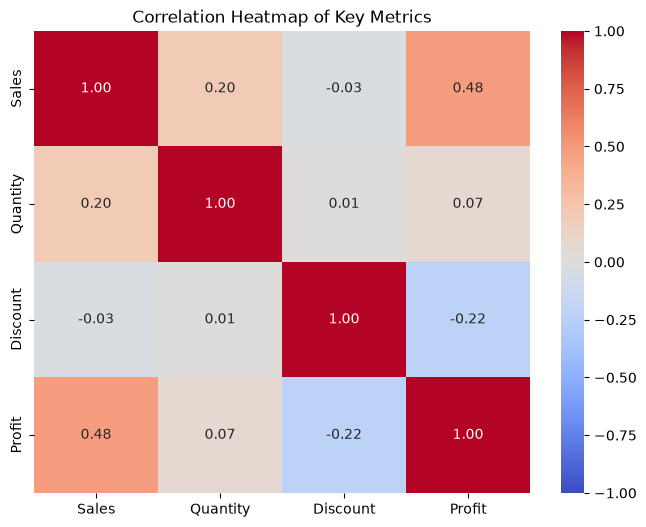

In [17]:
# Plot 8: Heatmap showing correlation between Sales, Profit, Discount & Quantity
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Metrics')

**Key Insight:** Correlation Matrix of Key Metrics: The heatmap statistically confirms the patterns seen in the other charts. There is a notable positive correlation (0.48) between Sales and Profit, meaning higher sales generally yield higher profit.
However, there is a negative correlation (-0.22) between Discount and Profit, statistically validating that as discounts increase, profits decrease.

**Question 9: What does the mix of sales look like across product categories and their sub-categories**

In [18]:
fig_sunburst = px.sunburst(df, path=['Category', 'Sub-Category'], values='Sales', title="Sales Breakdown: Category to Sub-Category")

fig_sunburst

**Question 10: Is shipping efficient, and does ship mode matter?**

In [19]:
# Average ship days by region
avg_ship = df.groupby("Region")["Ship Days"].mean().round(2).sort_values(ascending=False)
print(avg_ship)

Region
Central    4.06
South      3.96
West       3.93
East       3.91
Name: Ship Days, dtype: float64


In [20]:
# Extract ship data from dataframe
ship = df.groupby("Ship Mode").agg(AvgShipDays=("Ship Days", "mean"), Orders=("Order ID", "nunique"),
                                   Sales=("Sales", "sum"), Profit=("Profit", "sum"))

# Calculate percentage profit margin for the ship data
ship["Margin %"] = (ship["Profit"] / ship["Sales"] * 100).round(2)

In [21]:
# Avarage ship days, Orders, sales, Profit and Profit margin across ship mode
print(ship.round(2).sort_values('Profit', ascending=False))

                AvgShipDays  Orders       Sales     Profit  Margin %
Ship Mode                                                           
Standard Class         5.01    2994  1357288.72  163899.32     12.08
Second Class           3.24     964   457585.70   56994.01     12.46
First Class            2.18     787   351391.58   48952.53     13.93
Same Day               0.04     264   128363.12   15891.76     12.38


In [22]:
# Ship Mode: Sales vs Profit
ship_summary = ship.reset_index()[['Ship Mode', 'Sales', 'Profit']]

# Plot a grouped bar chart of sales and profit by ship mode
fig_ship = px.bar(ship_summary, x='Ship Mode', y=['Sales', 'Profit'], barmode='group',
    title='Sales and Profit by Ship Mode', labels={'value': 'Amount ($)', 'Ship Mode': '', 'variable': ''},
    color_discrete_map={'Sales': '#2980b9', 'Profit': '#27ae60'}
)

fig_ship